# Single-agent active causal discovery — overnight findings

238 runs across 73 configurations, 15 August 2026. Everything here reads
`results/all_runs.csv`, which `scripts/analyse_sweep.py` generates from the raw result
files in `results/raw/`. No number is transcribed by hand.

**The result:** the agent beats the greedy information-gain oracle at d=4, d=5 and d=6.

**The story:** 61 configurations of the original network failed first. A supervised probe
showed why none of them could have worked — the network could not express the mapping it
was being asked to learn.

Run the cells in order. The last section is set up for you to slice the data yourself.

## Setup

In [1]:
import json, glob, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works whether you launch from the repo root or from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
assert RESULTS.exists(), f"can't find results/ from {Path.cwd()}"

runs = pd.read_csv(RESULTS / "all_runs.csv")
print(f"{len(runs)} runs across {runs.tag.nunique()} configurations")
runs.head(3)

238 runs across 76 configurations


,tag,arm,d,observation,seed,gap_closed,gap_closed_sampled,solve_rate,greedy_solve_rate,mean_cost,...,episodes_per_update,arch,shaping_coef,include_counts,no_pass,n_dags,n_mecs,singleton_fraction,git_commit,torch
0,budget_10,budget,5,edge_marginals,0,-2.785908,-0.113821,0.396667,0.98,6.783333,...,32,flat,0.0,False,False,29281,8782,0.089341,1c8870dc,2.6.0+cpu
1,budget_10,budget,5,edge_marginals,1,-3.859079,-0.111111,0.223333,0.98,8.103333,...,32,flat,0.0,False,False,29281,8782,0.089341,1c8870dc,2.6.0+cpu
2,budget_10,budget,5,edge_marginals,2,-2.108401,-0.075881,0.500000,0.98,5.950000,...,32,flat,0.0,False,False,29281,8782,0.089341,1c8870dc,2.6.0+cpu


In [2]:
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
GOOD, BAD, MUTED, ACCENT = "#2E7D5B", "#B3402F", "#8892A0", "#1F6F8B"

## 1. The headline

`gap_closed` is the primary metric: `(random − agent) / (random − greedy)` on episode cost,
with unsolved episodes charged at the full budget.

- **0.0** = no better than picking at random
- **1.0** = matches the greedy information-gain oracle
- **above 1.0** = beats it

The **minimum across seeds** is what counts, never the mean — a mean hides a lucky run.

In [3]:
summary = (runs.groupby(["tag", "arch", "d", "n_obs"], as_index=False)
           .agg(seeds=("gap_closed", "size"),
                passed=("passed", "sum"),
                min_gap=("gap_closed", "min"),
                median_gap=("gap_closed", "median"),
                max_gap=("gap_closed", "max"),
                solve=("solve_rate", "mean"),
                entropy=("final_entropy", "mean"),
                oracle_agreement=("optimal_rate", "mean"))
           .sort_values("min_gap", ascending=False))

summary.head(12).round(3)

,tag,arch,d,n_obs,seeds,passed,min_gap,median_gap,max_gap,solve,entropy,oracle_agreement
67,s6_d4_nobs5000,pernode,4,5000,3,3,1.283,1.326,1.326,1.000,0.537,0.808
65,s5_pernode_best_counts_shape,pernode,5,1000,3,3,1.276,1.296,1.299,0.998,0.570,0.671
69,s6_d5_nobs5000,pernode,5,5000,3,3,1.233,1.265,1.278,0.993,0.488,0.700
64,s5_pernode_best_counts_long,pernode,5,1000,3,3,1.229,1.259,1.284,0.996,0.696,0.635
8,d6_s2,pernode,6,1000,1,1,1.145,1.145,1.145,0.980,0.726,0.426
63,s5_pernode_best_counts,pernode,5,1000,5,5,1.116,1.241,1.304,0.996,0.566,0.627
6,d6_s0,pernode,6,1000,1,1,1.098,1.098,1.098,0.987,0.589,0.492
7,d6_s1,pernode,6,1000,1,1,1.098,1.098,1.098,0.987,0.958,0.445
68,s6_d5_nobs20000,pernode,5,20000,3,3,1.060,1.091,1.110,0.998,0.638,0.718
59,s4_everything,flat,5,1000,3,0,0.450,0.455,0.457,0.999,0.840,0.289


### The configurations that passed

A run passes only if it clears **all four** criteria: gap closed >= 0.80, no under-acting,
solve rate within 5 points of greedy's, and no collapse between the deterministic and
sampled policies.

In [4]:
winners = summary[summary.passed > 0].copy()
print(f"{len(winners)} configurations had at least one passing seed.")
print(f"Architectures among them: {sorted(winners.arch.unique())}")
print(f"Flat-network configurations that passed: "
      f"{len(summary[(summary.arch == 'flat') & (summary.passed > 0)])} "
      f"of {len(summary[summary.arch == 'flat'])}")
winners.round(3)

11 configurations had at least one passing seed.
Architectures among them: ['pernode']
Flat-network configurations that passed: 0 of 64


,tag,arch,d,n_obs,seeds,passed,min_gap,median_gap,max_gap,solve,entropy,oracle_agreement
67,s6_d4_nobs5000,pernode,4,5000,3,3,1.283,1.326,1.326,1.000,0.537,0.808
65,s5_pernode_best_counts_shape,pernode,5,1000,3,3,1.276,1.296,1.299,0.998,0.570,0.671
69,s6_d5_nobs5000,pernode,5,5000,3,3,1.233,1.265,1.278,0.993,0.488,0.700
64,s5_pernode_best_counts_long,pernode,5,1000,3,3,1.229,1.259,1.284,0.996,0.696,0.635
8,d6_s2,pernode,6,1000,1,1,1.145,1.145,1.145,0.980,0.726,0.426
63,s5_pernode_best_counts,pernode,5,1000,5,5,1.116,1.241,1.304,0.996,0.566,0.627
6,d6_s0,pernode,6,1000,1,1,1.098,1.098,1.098,0.987,0.589,0.492
7,d6_s1,pernode,6,1000,1,1,1.098,1.098,1.098,0.987,0.958,0.445
68,s6_d5_nobs20000,pernode,5,20000,3,3,1.060,1.091,1.110,0.998,0.638,0.718
66,s5_pernode_best_d4,pernode,4,1000,5,1,0.239,0.805,1.257,0.977,0.557,0.622


## 2. The arc: from failure to beating the oracle

Each dot is one seed. The large dot is the worst seed — the number the criteria use.

Read this top to bottom: the original network fails, tuning helps a little, action memory
helps more, and the architecture change is what crosses the line. The `flat, all fixes`
row is the control: same settings, old network.

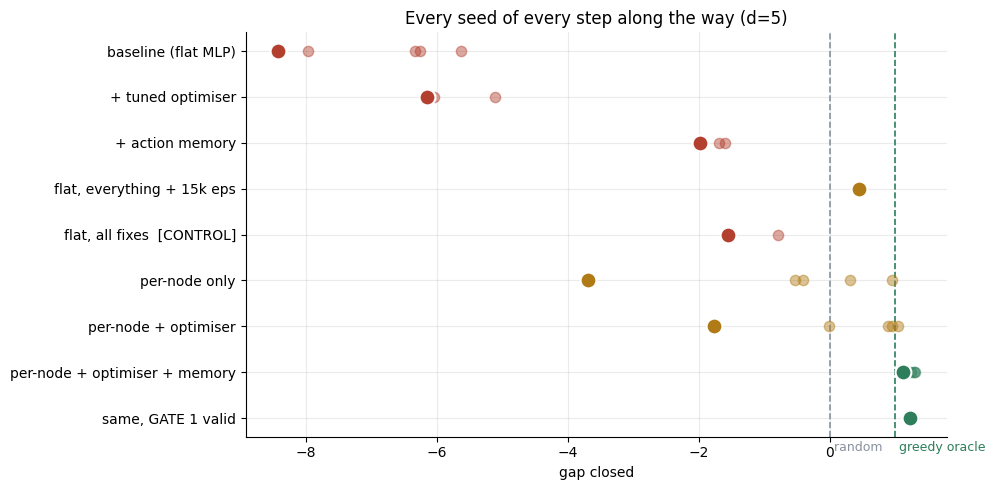

In [5]:
ARC = [
    ("core_d5_edge_marginals",        "baseline (flat MLP)"),
    ("s4_best_nocounts",              "+ tuned optimiser"),
    ("s4_counts_best",                "+ action memory"),
    ("s4_everything",                 "flat, everything + 15k eps"),
    ("s5_flat_control",               "flat, all fixes  [CONTROL]"),
    ("s5_pernode",                    "per-node only"),
    ("s5_pernode_best",               "per-node + optimiser"),
    ("s5_pernode_best_counts",        "per-node + optimiser + memory"),
    ("s6_d5_nobs5000",                "same, GATE 1 valid"),
]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (tag, label) in enumerate(ARC):
    vals = runs.loc[runs.tag == tag, "gap_closed"].dropna().values
    if not len(vals):
        continue
    colour = GOOD if vals.min() >= 0.8 else (BAD if vals.max() < 0 else "#B07A16")
    ax.scatter(vals, [i] * len(vals), s=55, color=colour, alpha=0.45, zorder=3)
    ax.scatter([vals.min()], [i], s=130, color=colour, zorder=4,
               edgecolor="white", linewidth=1.5)

ax.axvline(0, color=MUTED, ls="--", lw=1.2)
ax.axvline(1, color=GOOD, ls="--", lw=1.2)
ax.text(0, len(ARC) - 0.3, " random", color=MUTED, fontsize=9)
ax.text(1, len(ARC) - 0.3, " greedy oracle", color=GOOD, fontsize=9)
ax.set_yticks(range(len(ARC)))
ax.set_yticklabels([l for _, l in ARC])
ax.set_xlabel("gap closed")
ax.set_title("Every seed of every step along the way (d=5)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 3. Entropy separated pass from fail better than any hyperparameter

Policy entropy measures how undecided the policy is. At d=5 the maximum is ln(6) = 1.79,
meaning "completely random".

Every failing configuration ended between roughly 1.2 and 1.6 — the policy never sharpened,
so its `argmax` was close to arbitrary. Every passing one ended near 0.5–0.7.

This is worth remembering as a first diagnostic on any future run.

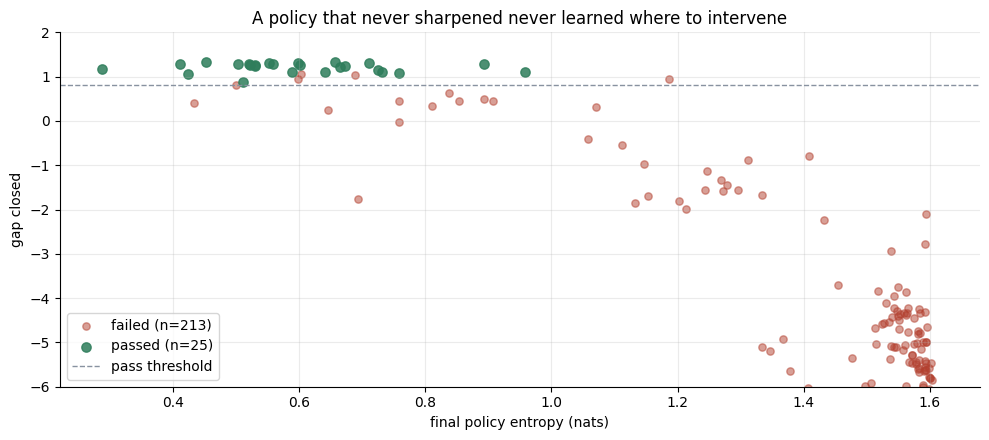

        count   mean    min    max
passed                            
False   213.0  1.475  0.433  1.613
True     25.0  0.600  0.287  0.958


In [6]:
fig, ax = plt.subplots()
passed_runs = runs[runs.passed]
failed_runs = runs[~runs.passed]
ax.scatter(failed_runs.final_entropy, failed_runs.gap_closed, s=28,
           color=BAD, alpha=0.5, label=f"failed (n={len(failed_runs)})")
ax.scatter(passed_runs.final_entropy, passed_runs.gap_closed, s=45,
           color=GOOD, alpha=0.85, label=f"passed (n={len(passed_runs)})")
ax.axhline(0.8, color=MUTED, ls="--", lw=1, label="pass threshold")
ax.set_xlabel("final policy entropy (nats)")
ax.set_ylabel("gap closed")
ax.set_ylim(-6, 2)
ax.set_title("A policy that never sharpened never learned where to intervene")
ax.legend()
plt.tight_layout(); plt.show()

print(runs.groupby("passed").final_entropy.describe()[["count", "mean", "min", "max"]].round(3))

## 4. The stage-1 lever sweep — thirteen levers, none of them the answer

Each of these varied ONE setting away from a fixed baseline. Not one passed. The uniformity
is the finding: the problem was not in the region any lever explored.

**Caveat that matters:** these were all measured at `n_obs=1000`, where GATE 1 fails at d=5
(see section 6). They may not transfer. Re-running this sweep at `n_obs=5000` is an open task.

In [7]:
lever_tags = runs[~runs.tag.str.startswith(("s2_", "s3_", "s4_", "s5_", "s6_", "core", "d6"))]
levers = (lever_tags.groupby("tag", as_index=False)
          .agg(seeds=("gap_closed", "size"), min_gap=("gap_closed", "min"),
               median=("gap_closed", "median"), solve=("solve_rate", "mean"),
               entropy=("final_entropy", "mean"))
          .sort_values("min_gap", ascending=False))
print(f"{len(levers)} lever configurations, "
      f"{int((levers.min_gap >= 0.8).sum())} passing")
levers.round(3)

30 lever configurations, 0 passing


,tag,seeds,min_gap,median,solve,entropy
0,budget_10,3,-3.859,-2.786,0.373,1.582
28,train_episodes_12000,3,-5.103,-5.103,0.567,1.540
22,prior_p_0.2,3,-5.375,-4.386,0.589,1.546
9,gamma_1.0,3,-5.663,-5.465,0.541,1.586
6,episodes_per_update_16,3,-5.910,-5.035,0.548,1.533
10,hidden_256,3,-5.985,-5.078,0.571,1.533
17,lr_0.001,3,-6.244,-5.354,0.531,1.495
4,entropy_coef_0.01,3,-6.648,-6.256,0.460,1.580
13,identify_threshold_0.9,3,-6.813,-6.643,0.241,1.599
18,n_int_400,3,-6.908,-6.578,0.443,1.582


## 5. The probe — where the failure actually was

Two explanations looked identical from outside:

- **A.** The observation carries the answer, but PPO can't find it.
- **B.** The observation doesn't carry a decodable answer at all.

The probe separates them. Train the agent's *own* network on the agent's *own* observation
to predict the oracle's best target, with full supervision and no exploration problem. If it
still can't learn the mapping, the problem isn't reward or exploration.

It could — but only with the right architecture. That is the whole result.

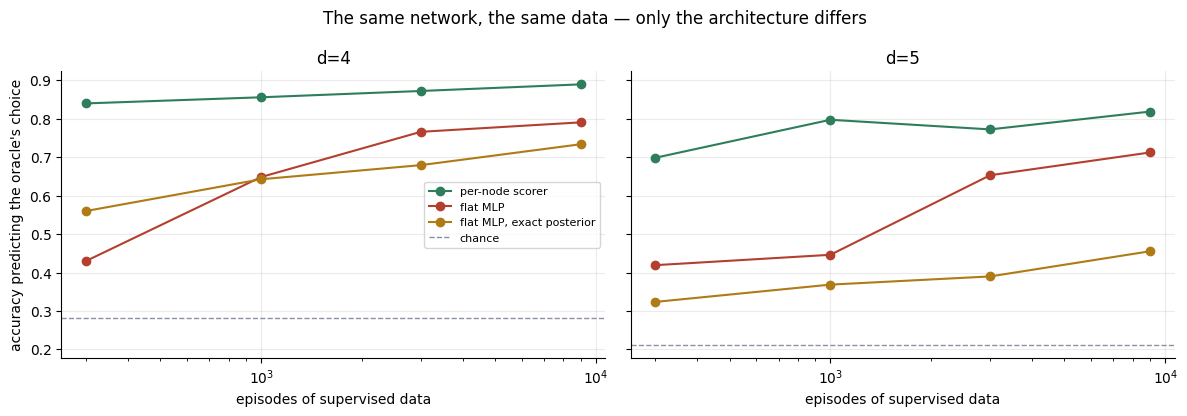

,d,episodes,condition,accuracy,chance,majority
0,4,3000,edge_marginals,0.766,0.284,0.262
5,4,300,edge_marginals/flat,0.430,0.287,0.260
2,4,1000,edge_marginals/flat,0.648,0.277,0.282
8,4,3000,edge_marginals/flat,0.766,0.284,0.262
11,4,9000,edge_marginals/flat,0.791,0.280,0.283
6,4,300,edge_marginals/pernode,0.840,0.287,0.260
3,4,1000,edge_marginals/pernode,0.856,0.277,0.282
9,4,3000,edge_marginals/pernode,0.872,0.284,0.262
12,4,9000,edge_marginals/pernode,0.890,0.280,0.283
1,4,3000,posterior,0.679,0.284,0.262


In [8]:
rows = []
for path in sorted(glob.glob(str(RESULTS / "probe" / "*.json"))):
    payload = json.load(open(path))
    for condition, stats in payload.get("conditions", {}).items():
        rows.append({"d": payload["d"], "episodes": payload["episodes"],
                     "condition": condition,
                     "accuracy": stats["probe_accuracy"],
                     "chance": stats["chance_accuracy"],
                     "majority": stats["majority_accuracy"]})
probe = pd.DataFrame(rows).sort_values(["d", "condition", "episodes"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
styles = {"edge_marginals/pernode": (GOOD, "per-node scorer"),
          "edge_marginals/flat": (BAD, "flat MLP"),
          "posterior/flat": ("#B07A16", "flat MLP, exact posterior")}
for ax, d in zip(axes, [4, 5]):
    subset = probe[probe.d == d]
    for condition, (colour, label) in styles.items():
        line = subset[subset.condition == condition].sort_values("episodes")
        if len(line) > 1:
            ax.plot(line.episodes, line.accuracy, "o-", color=colour, label=label)
    chance = subset.chance.mean()
    ax.axhline(chance, color=MUTED, ls="--", lw=1, label="chance")
    ax.set_xscale("log"); ax.set_xlabel("episodes of supervised data")
    ax.set_title(f"d={d}")
axes[0].set_ylabel("accuracy predicting the oracle's choice")
axes[0].legend(fontsize=8)
plt.suptitle("The same network, the same data — only the architecture differs")
plt.tight_layout(); plt.show()

probe.round(3)

**How to read this.** The per-node scorer at 300 episodes beats the flat network at 9,000 —
roughly a 30x sample-efficiency advantage — and has a higher ceiling. Notice too that the
flat network reading the *exact posterior* does worse than the per-node scorer reading the
*lossy* edge-marginal summary. The difficulty was never the information content.

**Note the ceiling is ~0.89, not 1.0.** The oracle's score depends on each node's
*descendants* — reachability, which is inherently multi-hop — while this architecture does a
single round of neighbour aggregation. That gap is a concrete lead for a deeper
message-passing network.

## 6. GATE 1 — the check that stopped holding

The environment is supposed to satisfy one exact property: the fraction of problems solvable
*without* intervening must equal the fraction of graphs alone in their Markov equivalence
class. That number is computable from the graph space, so it is a prediction, not a vibe.

It was checked at d=3, passed, and was thereafter assumed.

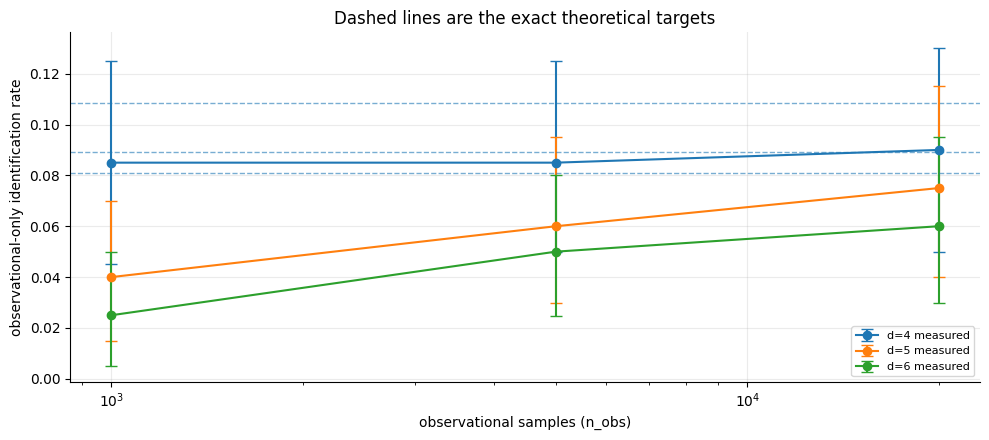

,d,n_obs,target,measured,ci_low,ci_high,passes
0,4,1000,0.1087,0.085,0.0450,0.125,True
1,4,5000,0.1087,0.085,0.0500,0.125,True
2,4,20000,0.1087,0.090,0.0500,0.130,True
3,5,1000,0.0893,0.040,0.0150,0.070,False
4,5,5000,0.0893,0.060,0.0300,0.095,True
5,5,20000,0.0893,0.075,0.0400,0.115,True
6,6,1000,0.0810,0.025,0.0050,0.050,False
7,6,5000,0.0810,0.050,0.0249,0.080,False
8,6,20000,0.0810,0.060,0.0300,0.095,True


In [9]:
rows = []
for path in sorted(glob.glob(str(RESULTS / "gate1" / "*.json"))):
    payload = json.load(open(path))
    for n_obs, measured in payload["measured"].items():
        rows.append({"d": payload["d"], "n_obs": int(n_obs),
                     "target": payload["target"], "measured": measured["rate"],
                     "ci_low": measured["ci"][0], "ci_high": measured["ci"][1],
                     "passes": measured["covers_target"]})
gate = pd.DataFrame(rows).sort_values(["d", "n_obs"])

fig, ax = plt.subplots()
for d, group in gate.groupby("d"):
    ax.errorbar(group.n_obs, group.measured,
                yerr=[group.measured - group.ci_low, group.ci_high - group.measured],
                fmt="o-", capsize=4, label=f"d={d} measured")
    ax.axhline(group.target.iloc[0], ls="--", lw=1, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel("observational samples (n_obs)")
ax.set_ylabel("observational-only identification rate")
ax.set_title("Dashed lines are the exact theoretical targets")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

gate.round(4)

**What this cost.** At the default `n_obs=1000` the gate fails at d=5 and d=6. Every d=5 run
in this project — including the first version of the headline — used an observational phase
too short to pin down the equivalence class.

**What survives:** `gap_closed` is measured against baselines evaluated in the *same*
environment, so rankings and the architecture comparison hold.
**What doesn't:** the claim that the environment matched its specification, and any
comparison of *absolute* difficulty across sizes.

The winner was re-run where the gate passes, and came back stronger (+1.233 vs +1.116).
GATE 1 now runs automatically on every training run.

## 7. Training curves

Entropy over training, for any configuration you like. Change `TAGS` below.

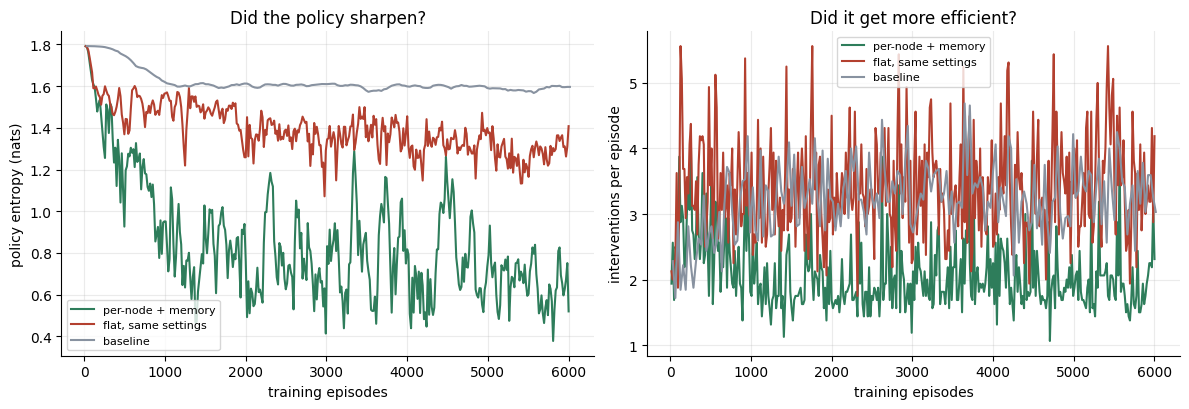

In [10]:
TAGS = ["s5_pernode_best_counts", "s5_flat_control", "core_d5_edge_marginals"]
LABELS = {"s5_pernode_best_counts": "per-node + memory",
          "s5_flat_control": "flat, same settings",
          "core_d5_edge_marginals": "baseline"}
COLOURS = {"s5_pernode_best_counts": GOOD, "s5_flat_control": BAD,
           "core_d5_edge_marginals": MUTED}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for tag in TAGS:
    path = RESULTS / "raw" / f"{tag}.json"
    if not path.exists():
        print(f"missing: {tag}"); continue
    payload = json.load(open(path))
    history = payload["training_history"].get("0", [])
    if not history:
        continue
    episodes = [h["episodes"] for h in history]
    colour = COLOURS.get(tag, ACCENT)
    label = LABELS.get(tag, tag)
    axes[0].plot(episodes, [h["entropy"] for h in history], color=colour, label=label)
    axes[1].plot(episodes, [h["mean_length"] for h in history], color=colour, label=label)

axes[0].set_ylabel("policy entropy (nats)"); axes[0].set_title("Did the policy sharpen?")
axes[1].set_ylabel("interventions per episode"); axes[1].set_title("Did it get more efficient?")
for ax in axes:
    ax.set_xlabel("training episodes"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The left panel is the whole story in one picture. The right panel shows the baseline
settling at random-policy cost: it learned not to give up, and nothing about where to
intervene.

## 8. Explore it yourself

`runs` is one row per (configuration, seed) with every lever as a column. Some starting
points below — edit freely.

In [11]:
# What columns are available?
sorted(runs.columns.tolist())

['arch',
 'arm',
 'budget',
 'cost_ci_high',
 'cost_ci_low',
 'd',
 'distinct_targets',
 'entropy_coef',
 'episodes_per_update',
 'final_entropy',
 'gamma',
 'gap_closed',
 'gap_closed_sampled',
 'git_commit',
 'greedy_solve_rate',
 'hidden',
 'identify_threshold',
 'include_counts',
 'informative_fraction',
 'intervene_scale',
 'lr',
 'mean_cost',
 'mean_regret',
 'n_dags',
 'n_int',
 'n_mecs',
 'n_obs',
 'no_pass',
 'observation',
 'optimal_rate',
 'passed',
 'prior',
 'prior_p',
 'ref_edge_greedy_cost',
 'ref_greedy_cost',
 'ref_no_intervention_solve',
 'ref_random_cost',
 'repeat_rate',
 'seed',
 'shaping_coef',
 'singleton_fraction',
 'solve_rate',
 'step_cost',
 'tag',
 'torch',
 'train_episodes',
 'train_seconds',
 'under_acting_rate']

In [12]:
# Compare architectures head to head, holding the other settings fixed.
head_to_head = runs[runs.tag.isin(["s6_d5_nobs5000", "s6_d5_nobs5000_flat"])]
head_to_head[["tag", "arch", "seed", "gap_closed", "solve_rate",
              "final_entropy", "optimal_rate", "repeat_rate"]].round(3)

,tag,arch,seed,gap_closed,solve_rate,final_entropy,optimal_rate,repeat_rate
217,s6_d5_nobs5000,pernode,0,1.265,0.993,0.523,0.699,0.103
218,s6_d5_nobs5000,pernode,1,1.278,0.993,0.412,0.692,0.094
219,s6_d5_nobs5000,pernode,2,1.233,0.993,0.530,0.711,0.121
220,s6_d5_nobs5000_flat,flat,0,-1.858,0.920,1.132,0.133,0.644
221,s6_d5_nobs5000_flat,flat,1,-0.971,0.967,1.147,0.206,0.598
222,s6_d5_nobs5000_flat,flat,2,-0.893,0.977,1.312,0.196,0.580


In [13]:
# Does any lever correlate with success across the whole matrix?
numeric = ["gap_closed", "final_entropy", "solve_rate", "optimal_rate",
           "lr", "hidden", "entropy_coef", "step_cost", "gamma",
           "episodes_per_update", "n_obs", "n_int", "budget"]
runs[numeric].corr()["gap_closed"].sort_values(ascending=False).round(3)

gap_closed             1.000
solve_rate             0.876
optimal_rate           0.774
hidden                 0.735
lr                     0.733
n_obs                  0.265
gamma                  0.030
step_cost             -0.003
n_int                 -0.034
entropy_coef          -0.056
budget                -0.361
episodes_per_update   -0.673
final_entropy         -0.753
Name: gap_closed, dtype: float64

In [14]:
# Pivot on anything: here, mean gap by architecture and problem size.
runs.pivot_table(index="arch", columns="d", values="gap_closed",
                 aggfunc=["mean", "max", "count"]).round(3)

mean                  max               count            
d             4      5      6      4      5      6     4      5    6
arch                                                                
flat    -10.517 -6.003    NaN -4.920  0.636    NaN  10.0  190.0  NaN
pernode   0.962  0.687  1.114  1.326  1.304  1.145   8.0   27.0  3.0

In [15]:
# Open any raw result file to see everything recorded for it.
example = json.load(open(RESULTS / "raw" / "s6_d5_nobs5000.json"))
print("top-level keys:", list(example))
print()
print("provenance:", json.dumps(example["provenance"], indent=2))
print()
print("references:", json.dumps(example["references"], indent=2))

top-level keys: ['args', 'tag', 'provenance', 'space', 'references', 'per_seed', 'training_history', 'summary']

provenance: {
  "git_commit": "edfc8bae5cceac6392f037e29df3c6ce0e0ffe0c",
  "python": "3.11.4",
  "numpy": "1.26.4",
  "torch": "2.6.0+cpu",
  "host": "node-d00a-119.myriad.ucl.ac.uk",
  "finished_utc": "2026-08-15T05:44:55Z"
}

references: {
  "random": {
    "solve_rate": 0.9933333333333333,
    "mean_cost": 3.296666666666667
  },
  "greedy_oracle": {
    "solve_rate": 0.99,
    "mean_cost": 1.9033333333333333
  },
  "edge_marginal_greedy": {
    "solve_rate": 0.9866666666666667,
    "mean_cost": 2.05
  },
  "no_intervention": {
    "solve_rate": 0.06666666666666667,
    "mean_cost": 18.666666666666668
  }
}


## 9. Where the numbers came from

    results/raw/<tag>.json    one file per configuration: args, provenance, references,
                              per-seed metrics (deterministic AND sampled), full training
                              history, and the pass/fail verdict
    results/probe/*.json      supervised probe results
    results/gate1/*.json      GATE 1 audit across d and n_obs
    results/all_runs.csv      the tidy table this notebook reads

To regenerate the CSV after adding runs:

    python -m scripts.analyse_sweep --results results/raw --out results/all

Every result file records the exact command line that produced it, plus the git commit and
package versions. Note the cluster ran `torch 2.6.0+cpu` and the laptop `2.10.0+cpu`; numpy
and scipy were pinned to match.